In [ ]:
# This script sets up the VPint library environment in Google Colab.
# It performs a clean installation, clones the repository, installs dependencies,
# and prepares the environment for satellite imagery interpolation tasks.
#
# Resources:
# - TPU requirement: Used TPU v6e1. GPU acceleration is beneficial for interpolation.
# - TEST1_SAFE_ZIP_T43QCD_20250513T090819 (TILE): Processing time per tile (for a 5490x5490 image):
#   - Section H (VPint2 Interpolation): Approximately 10 minutes.
#   - Section J (VPint2 Interpolation with Buffered Mask): Approximately 20 minutes (TPU RAM usage around 70 GB).
#   - Section L (Advanced VPint2 Interpolation with Auto-Adaptation): Maximum 1 hour (TPU RAM usage around 150 GB).
#   - Other sections (like data loading/visualization): Within a minute.
#
# Authors:
# - Jayson J. Jariwala
# - Arkadipta Das
# - Mewan Banshan War
# - Venkatesh Nayak
#
# Study Area: TAPI sub-districts, near SURAT district (specifically TAPI district tile processing).
# Compute Units Used: Approximately 8 compute units during processing, costing

In [ ]:
# Go to the root content directory to ensure consistent cloning location
%cd /content

# [A]. Aggressive cleanup of any previous VPint installations

# Uninstall any previously installed VPint package
!pip uninstall -y VPint

# Remove any cloned VPint directories
# !rm -rf VPint VPint2 # Remove cloned directories
!rm -rf VPint
!rm -rf VPint2

# Explicitly remove the egg file that seems to cause persistent issues
!rm -rf /usr/local/lib/python3.12/dist-packages/VPint-0.2.4-py3.12.egg
!rm -rf /usr/local/lib/python3.12/dist-packages/VPint.egg-info/

/content
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/VPint-0.2.4-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
Found existing installation: VPint 0.2.4
Uninstalling VPint-0.2.4:
  Successfully uninstalled VPint-0.2.4


In [ ]:
# [B]. Clone the VPint repository from LaurensArp
# installation. To create a new environment for VPint2 using conda,
# Conda is not installed by default in Colab. Using pip for package installation.
!git clone https://github.com/LaurensArp/VPint.git

# Change into the cloned directory
%cd VPint

# Install dependencies from requirements.txt
!pip install -r requirements.txt

# 3. Install the package in editable mode to ensure correct path resolution
!python setup.py install
!pip install -e .

Cloning into 'VPint'...
remote: Enumerating objects: 889, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 889 (delta 49), reused 61 (delta 27), pack-reused 796 (from 1)
Receiving objects: 100% (889/889), 5.95 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (359/359), done.
/content/VPint
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setupto

In [ ]:
# [C]
# This section imports the necessary classes and utility functions from the VPint library.
# It ensures that the required components like 'VPint2_interpolator' and
# 'load_product', 'normalise_and_visualise' from 'EO_utils' are available for use.

#Import VPint modules, check before running main module

# VPint2_interpolator is found in VPint/VPint2.py
from VPint.VPint2 import VPint2_interpolator

# from VPint.utils.EO_wrapper import load_product, load_product_windowed, normalise_and_visualise
from VPint.utils.EO_utils import load_product, load_product_windowed, normalise_and_visualise, normalise_and_visualise_single

# Numpy is also imported for numerical operations.
import numpy as np

In [ ]:
# [D]. Verify VPint & VPint2
# This section verifies the successful installation and accessibility of the VPint library
# by listing directory contents and displaying the content of key Python files.

# Verify the contents of the root cloned directory
!ls -F /content/VPint

# Verify the contents of the actual Python package directory
!ls -F /content/VPint/VPint

# Now, try to cat the files from their correct paths
!cat /content/VPint/VPint/VPint2.py

# !cat /content/VPint2/VPint/utils/EO_wrapper.py
!cat /content/VPint/VPint/utils/EO_wrapper.py

!cat /content/VPint/README.md

build/	examples/    README.md		    setup.py  VPint.egg-info/
dist/	LICENSE      requirements_slim.txt  test/
docs/	MANIFEST.in  requirements.txt	    VPint/
__init__.py  MRP.py  __pycache__/  SD_MRP.py  utils/  VPint2.py  WP_MRP.py
"""Wrapper for VPint code; most of the VPint2 functionality is already contained in the core code.
This module aims to improve the ease of use of VPint2 for EO tasks.
"""

import numpy as np

import multiprocessing


from .WP_MRP import *

class VPint2_interpolator():
    def __init__(self, target, features, mask=None, buffer_mask=False, mask_buffer_size=5, mask_buffer_passes=1, bands_first=False, clip_target=None, clip_features=None, dtype=None, **kwargs):
        assert target.shape == features.shape
        assert len(target.shape) == 3
        assert len(features.shape) == 3

        if(dtype is not None):
            self.DTYPE = dtype
        else:
            self.DTYPE = np.float32

        target = target.astype(self.DTYPE)
        features = feature

In [ ]:
#import inspect
#from VPint.utils.EO_utils import load_product

#print(inspect.getsource(load_product))

def load_product(path, keep_bands=["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B11", "B12"],
                        bands_10m={"B2":1, "B3":2, "B4":3, "B8":7},
                        bands_20m={"B5":4, "B6":5, "B7":6, "B8A":8, "B11":10, "B12":11, "CLD":12},
                        bands_60m={"B1":0, "B9":9}):

    grid = None
    size_y = -1
    size_x = -1

    scales = [bands_10m, bands_20m, bands_60m, {}] # For bands that have multiple resolutions

    with rasterio.open(path) as raw_product:
        product = raw_product.subdatasets

    # Initialise grid
    with rasterio.open(product[1]) as bandset:
        size_y = bandset.profile['height']
        size_x = bandset.profile['width']
        grid = np.zeros((size_y, size_x, len(keep_bands))).astype(np.uint16)


    # Iterate over band sets (resolutions)
    resolution_index = 0
    for bs in product:
        with rasterio.open(bs, dtype="uint16") as bandset:
            desc = bandset.descriptions
            s

In [ ]:
# [E]. Mount Google Drive to access files

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


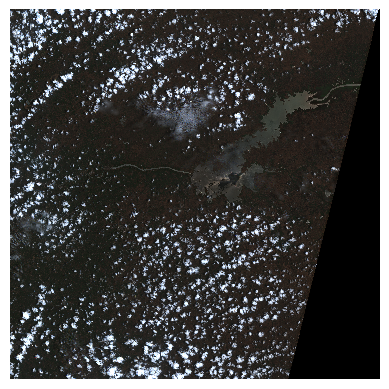

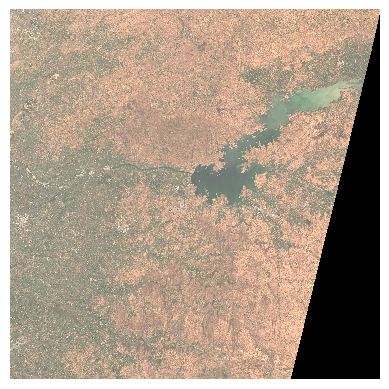

In [ ]:
# [F]. Data Loading and Visualization
# This section covers the initial data loading and visualization steps. We load the cloudy target image and the cloud-free features image from our prepared dataset. These images are then normalized and displayed to provide a visual understanding of the input data before any interpolation is applied.

# Import necessary classes from VPint library for interpolation and utility functions
from VPint.VPint2 import VPint2_interpolator
from VPint.utils.EO_utils import load_product, load_product_windowed, normalise_and_visualise, normalise_and_visualise_single
import rasterio # Import rasterio for georeferencing extraction

# Define the path to the target satellite imagery data (cloudy image)
# target_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2B_MSIL2A_20250513T052649_N0511_R105_T43QCD_20250513T074137.zip"
target_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip"
# Define the path to the features satellite imagery data (cloud-free image for reference)
#features_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2B_MSIL2A_20250314T052649_N0511_R105_T43QCD_20250314T095315.zip"
features_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip"

# Load the target product using the VPint utility function
target = load_product(target_path)
# Load the features product using the VPint utility function
features = load_product(features_path)

# Extract georeferencing information from one of the subdatasets of the target product
original_transform = None
original_crs = None
with rasterio.open(target_path) as raw_product:
    product_subdatasets = raw_product.subdatasets
    if product_subdatasets:
        # Open the first subdataset to get its transform and CRS
        with rasterio.open(product_subdatasets[0]) as src:
            original_transform = src.transform
            original_crs = src.crs


# Normalise and visualise the target image for inspection
normalise_and_visualise(target)
# Normalise and visualise the features image for inspection
normalise_and_visualise(features)

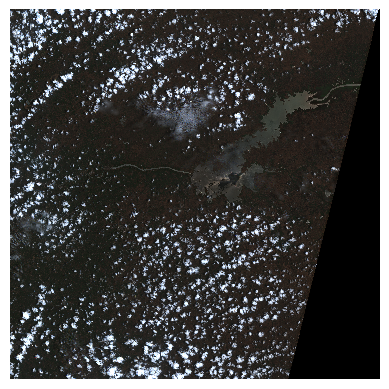

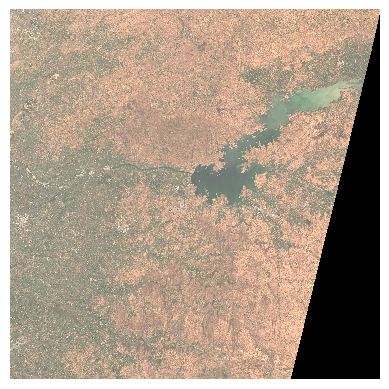

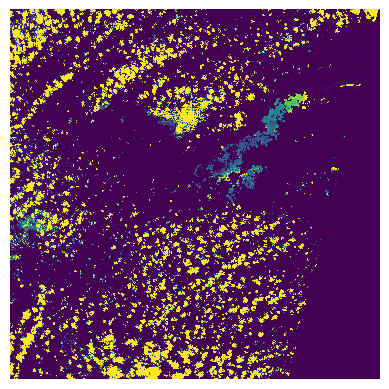

In [ ]:
# [G-1]. Data Loading and Visualization of Windowed Patches and Cloud Mask
# This section focuses on loading a specific 256x256 pixel patch from the satellite imagery
# using offsets to define the window. It also loads a corresponding cloud mask.
# Finally, it visualizes the windowed target, features, and the cloud mask.

# --- Optional: Windowed data loading (commented out) ---
# 256 x 256 patch
## y_size = 512
## x_size = 512
# Offsets to just read at the top-right of the image
## y_offset = 0
## x_offset = 0

# Perform the windowed data loading
## target = load_product_windowed(target_path, y_size, x_size, y_offset, x_offset)
## features = load_product_windowed(features_path, y_size, x_size, y_offset, x_offset)

# Also load a cloud mask included in the data product
## mask = load_product_windowed(target_path, y_size, x_size, y_offset, x_offset, keep_bands=["CLD"], bands_20m={"CLD":0})[:,:,0]


# ---------------------------------------------------------
# ---------------------------------------------------------

# [G-2]. Data Loading and Visualization of Entire Scene and Cloud Mask
# This section focuses on loading the entire satellite imagery scene.
# It loads the full target, features, and corresponding cloud mask.
# Finally, it visualizes the target, features, and the cloud mask.

# --- Active: Full scene data loading ---
# Perform the full scene data loading
# target = load_product(target_path) # already assigned in previous section F
# features = load_product(features_path) # already assigned in previous section F

# Also load a cloud mask included in the data product for the entire scene
mask = load_product(target_path, keep_bands=["CLD"], bands_20m={"CLD":0})[:,:,0]
# ---------------------------------------

# Visualise
normalise_and_visualise(target)
normalise_and_visualise(features)
normalise_and_visualise_single(mask, percentile_clip=False)

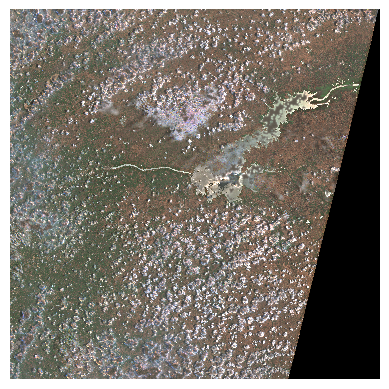

In [ ]:
# [H]. VPint2 Interpolation and Visualization
# This section performs the core interpolation using the VPint2_interpolator.
# It initializes the interpolator with the target, features, and cloud mask data.
# After running the interpolation, it visualizes the generated 'pred' (predicted) image.
VPint2 = VPint2_interpolator(target, features, mask=mask, bands_first=False, threshold=10) # Set bands_first to True if your data is C x H x W instead of H x W x C

# ORIGINAL IN CODE
pred = VPint2.run()
# pred = VPint2.run(resistance=True, prioritise_identity=True, clip_val=10000,
                    #auto_adapt=True, auto_adaptation_epochs=10, auto_adaptation_max_iter=100, auto_adaptation_strategy='random', auto_adaptation_proportion=0.8)


normalise_and_visualise(pred)

/usr/local/lib/python3.12/dist-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


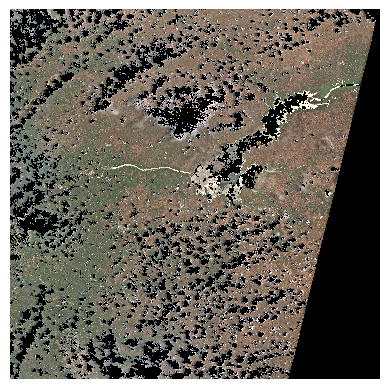

In [ ]:
# [I]. Displaying the target of the VPint2 Interpolator
# This section initializes the VPint2_interpolator again (or uses a previously initialized one).
# It then visualizes the 'target' data that was passed to the interpolator.
# This 'target' represents the input image *after* the cloud mask has been applied,
# indicating the areas that VPint2 will attempt to interpolate to remove cloud cover,

VPint2 = VPint2_interpolator(target, features, mask=mask, bands_first=False, threshold=10)
normalise_and_visualise(VPint2.target)

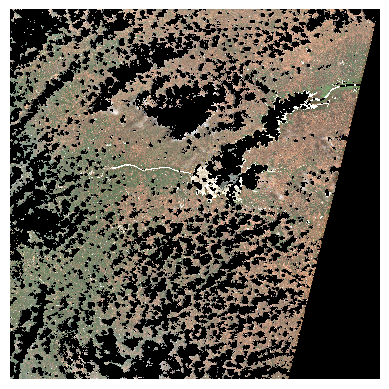

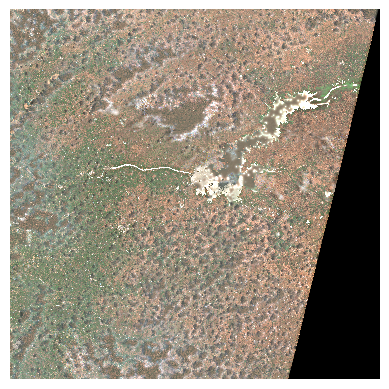

In [ ]:
# [J]. VPint2 Interpolation with Buffered Mask
# This section demonstrates VPint2 interpolation with a buffered cloud mask.
# The 'buffer_mask=True' argument applies a buffer around the original mask,
# expanding the masked area (e.g., to account for cloud shadows or partial clouds),
# which can improve the interpolation quality as discussed in the referenced blog post (https://adaresearch.wordpress.com/2024/08/07/vpint2_cloud_removal/).
# 'mask_buffer_size' controls the extent of this buffer.
# After buffering, the modified target (VPint2.target) is visualized,
# and then the VPint2 algorithm is run to produce the interpolated 'pred' image,
# which is also visualized.
VPint2 = VPint2_interpolator(target, features, mask=mask, buffer_mask=True, mask_buffer_size=5, bands_first=False, threshold=10)
normalise_and_visualise(VPint2.target) # Visualise the buffered mask
pred = VPint2.run() # Run the algorithm

normalise_and_visualise(pred)

In [ ]:
print(f"Original Transform: {original_transform}")
print(f"Original CRS: {original_crs}")

Original Transform: | 10.00, 0.00, 300000.00|
| 0.00,-10.00, 2400000.00|
| 0.00, 0.00, 1.00|
Original CRS: EPSG:32643


In [ ]:
print(product_subdatasets[0])

SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643


In [ ]:
# [K]. Save Interpolated Image as GeoTIFF
# This section saves the generated interpolated image (`pred`) as a GeoTIFF file to Google Drive.
# It uses the `rasterio` library for GeoTIFF creation.
# Due to the 'NotGeoreferencedWarning' observed during data loading, this GeoTIFF will not
# contain accurate real-world georeferencing but will be saved with a default pixel-based transform.

import rasterio
import os
import numpy as np
from rasterio.transform import Affine
from google.colab import files

# Define output directory and file path in Google Drive
output_dir = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/"
os.makedirs(output_dir, exist_ok=True)
output_filepath = os.path.join(output_dir, "VPint2_InPolated_Manual_SURAT_T43QCD_20250513T090819.tif")

# The 'pred' array is in HWC (Height, Width, Channel) format
# Rasterio expects CWH (Channel, Height, Width) format for writing
pred_cwh = pred.transpose(2, 0, 1)

# Get image dimensions and data type from the transposed array
count, height, width = pred_cwh.shape
dtype = pred_cwh.dtype

# Use the extracted original transform and CRS for georeferencing
# Fallback to default if not found (though it should be found now)
transform_to_use = original_transform if original_transform is not None else Affine(1, 0, 0, 0, -1, 0)
crs_to_use = original_crs if original_crs is not None else None # Keep None if no original CRS found

# IMPORTANT: Scale the transform to match the 20m resolution of the 'pred' array.
# The 'original_transform' was extracted from a 10m band. Since 'pred' is 20m,
# the pixel size in the transform needs to be doubled.
if transform_to_use is not None:
    transform_to_use = transform_to_use * Affine.scale(2, 2)

# Save the interpolated image as a GeoTIFF
with rasterio.open(
    output_filepath,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=count,
    dtype=dtype,
    crs=crs_to_use,
    transform=transform_to_use
) as dst:
    dst.write(pred_cwh)

print(f"Interpolated image saved to: {output_filepath}")

# Provide an option to download the file directly
print("\nTo download the file directly to your local machine, execute the following command in a new cell:")
print(f"files.download('{output_filepath}')")

Interpolated image saved to: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_SURAT_T43QCD_20250513T090819.tif

To download the file directly to your local machine, execute the following command in a new cell:
files.download('/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_SURAT_T43QCD_20250513T090819.tif')


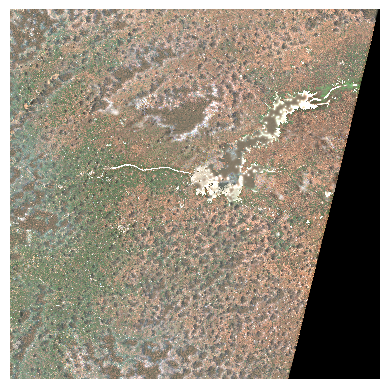

In [ ]:
# [L]. Advanced VPint2 Interpolation with Auto-Adaptation
# This section demonstrates an advanced application of the VPint2_interpolator.
# It initializes the interpolator with a buffered mask (`buffer_mask=True`) to account for surrounding cloud effects.
# The interpolation algorithm is then run with automatically configured extensions, as discussed in the VPint2 cloud removal blog post (https://adaresearch.wordpress.com/2024/08/07/vpint2_cloud_removal/).
# Key parameters used include `resistance=True`, `prioritise_identity=True`, and `clip_val=10000`.
# Furthermore, `auto_adapt=True` is enabled with specific `auto_adaptation_epochs`, `auto_adaptation_max_iter`,
# `auto_adaptation_strategy`, and `auto_adaptation_proportion` to dynamically optimize the interpolation process
# for improved results, especially in complex cloud scenarios.
VPint2 = VPint2_interpolator(target, features, mask=mask, buffer_mask=True, mask_buffer_size=5, bands_first=False, threshold=10)

# Run the algorithm with automatically configured extensions
pred = VPint2.run(resistance=True, prioritise_identity=True, clip_val=10000,
                    auto_adapt=True, auto_adaptation_epochs=10, auto_adaptation_max_iter=100, auto_adaptation_strategy='random', auto_adaptation_proportion=0.8)

normalise_and_visualise(pred)


In [ ]:
# [M]. Save Interpolated Image as GeoTIFF
# This section saves the generated interpolated image (`pred`) as a GeoTIFF file to Google Drive.
# It uses the `rasterio` library for GeoTIFF creation.
# Due to the 'NotGeoreferencedWarning' observed during data loading, this GeoTIFF will not
# contain accurate real-world georeferencing but will be saved with a default pixel-based transform.

import rasterio
import os
import numpy as np
from rasterio.transform import Affine
from google.colab import files

# Define output directory and file path in Google Drive
output_dir = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/"
os.makedirs(output_dir, exist_ok=True)
output_filepath = os.path.join(output_dir, "VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819.tif")

# The 'pred' array is in HWC (Height, Width, Channel) format
# Rasterio expects CWH (Channel, Height, Width) format for writing
pred_cwh = pred.transpose(2, 0, 1)

# Get image dimensions and data type from the transposed array
count, height, width = pred_cwh.shape
dtype = pred_cwh.dtype

# Use the extracted original transform and CRS for georeferencing
# Fallback to default if not found (though it should be found now)
transform_to_use = original_transform if original_transform is not None else Affine(1, 0, 0, 0, -1, 0)
crs_to_use = original_crs if original_crs is not None else None # Keep None if no original CRS found

# IMPORTANT: Scale the transform to match the 20m resolution of the 'pred' array.
# The 'original_transform' was extracted from a 10m band. Since 'pred' is 20m,
# the pixel size in the transform needs to be doubled.
if transform_to_use is not None:
    transform_to_use = transform_to_use * Affine.scale(2, 2)

# Save the interpolated image as a GeoTIFF
with rasterio.open(
    output_filepath,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=count,
    dtype=dtype,
    crs=crs_to_use,
    transform=transform_to_use
) as dst:
    dst.write(pred_cwh)

print(f"Interpolated image saved to: {output_filepath}")

# Provide an option to download the file directly
print("\nTo download the file directly to your local machine, execute the following command in a new cell:")
print(f"files.download('{output_filepath}')")

Interpolated image saved to: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819.tif

To download the file directly to your local machine, execute the following command in a new cell:
files.download('/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819.tif')


Read source: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819.tif -> bands=12, shape=5490x5490
Original Band 1 min/max: 0.0 / 8108.0
Original Band 2 min/max: 0.0 / 19132.0
Original Band 3 min/max: 0.0 / 18426.0
Original Band 4 min/max: 0.0 / 19732.0
Original Band 5 min/max: 0.0 / 16846.0
Original Band 6 min/max: 0.0 / 15255.0
Original Band 7 min/max: 0.0 / 15149.0
Original Band 8 min/max: 0.0 / 19098.0
Original Band 9 min/max: 0.0 / 15747.0
Original Band 10 min/max: 0.0 / 15793.0
Original Band 11 min/max: 0.0 / 16996.0
Original Band 12 min/max: 0.0 / 16708.0


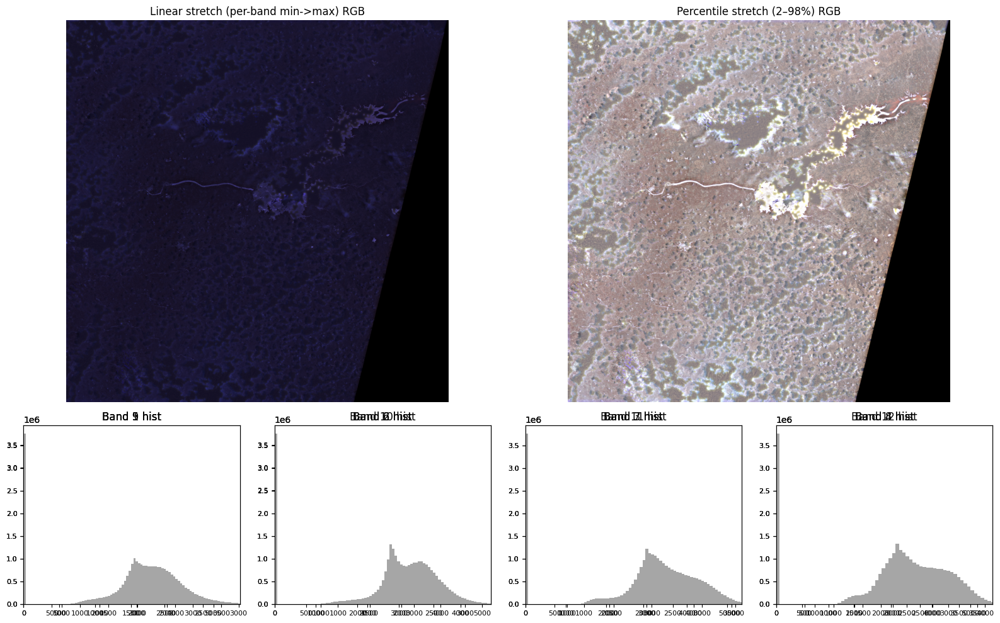

Saved local files:
  ./VPint2_VIS_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819_VIS_LIN_8bit.tif
  ./VPint2_VIS_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819_VIS_PERCENT_8bit.tif
Copied to Drive:
  /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819_VIS_LIN_8bit.tif
  /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819_VIS_PERCENT_8bit.tif

Verification for Linear 8-bit (local):
  dtype: uint8
  Band 1 min/max: 0 / 255
  Band 2 min/max: 0 / 255
  Band 3 min/max: 0 / 255
  Band 4 min/max: 0 / 255
  Band 5 min/max: 0 / 255
  Band 6 min/max: 0 / 255
  Band 7 min/max: 0 / 255
  Band 8 min/max: 0 / 255
  Band 9 min/max: 0 / 255
  Band 10 min/max: 0 / 255
  Band 11 min/max: 0 / 255
  Band 12 min/max: 0 / 255

Verification for Percentile 8-bit (local):
  dtype: uint8
  Band 1 min/max: 0 / 255
  B

In [ ]:
# [N]. Create and save linear & percentile 8-bit visualizations,
# display inline RGB composites + histograms, and print verification stats.
# Requirements: rasterio, numpy, matplotlib, google.colab (for Drive mount)
#
# Usage:
# 1. Upload your VPint2 GeoTIFF to the Colab working directory or set src_path to its path.
# 2. Set drive_path to a folder in your Google Drive where outputs should be saved.
# 3. Run the cell.

# --- Imports ---
import os
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# --- Mount Google Drive (Colab) ---
## try:
##     from google.colab import drive
##     drive.mount('/content/drive', force_remount=False)
##     print("Google Drive mounted at /content/drive")
## except Exception:
##     print("Google Drive mount skipped (not running in Colab or google.colab not available).")

# === User configuration ===
src_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819.tif"                 # <-- set to your VPint2 GeoTIFF filename/path
drive_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_VIS"  # <-- set desired Drive folder
local_out_dir = "./VPint2_VIS_Output"         # local output folder
rgb_bands = (3, 2, 1)                          # 1-based band indices for R,G,B in source
p_low, p_high = 2, 98                          # percentiles for percentile stretch
linear_out_name = "VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819_VIS_LIN_8bit.tif"
percentile_out_name = "VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819_VIS_PERCENT_8bit.tif"

# Create output directories
os.makedirs(local_out_dir, exist_ok=True)
if drive_path:
    Path(drive_path).mkdir(parents=True, exist_ok=True)

# --- Helper functions ---
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)  # (bands, H, W)
        meta = src.meta.copy()
        crs = src.crs
        transform = src.transform
    return arr, meta, crs, transform

def per_band_minmax(arr):
    bands = arr.shape[0]
    mins, maxs = [], []
    for i in range(bands):
        band = arr[i]
        valid = np.isfinite(band)
        if not valid.any():
            mins.append(np.nan); maxs.append(np.nan)
        else:
            mins.append(float(np.nanmin(band)))
            maxs.append(float(np.nanmax(band)))
    return mins, maxs

def linear_scale_band(band):
    valid = np.isfinite(band)
    out = np.zeros_like(band, dtype=np.uint8)
    if not valid.any():
        return out
    bmin = float(np.nanmin(band[valid]))
    bmax = float(np.nanmax(band[valid]))
    if bmax == bmin:
        clipped = np.clip(band, 0, 255)
        out = clipped.astype(np.uint8)
    else:
        norm = (band - bmin) / (bmax - bmin)
        out = np.clip(norm * 255.0, 0, 255).astype(np.uint8)
    return out

def percentile_scale_band(band, low_pct, high_pct):
    valid = np.isfinite(band)
    out = np.zeros_like(band, dtype=np.uint8)
    if not valid.any():
        return out
    low = float(np.nanpercentile(band[valid], low_pct))
    high = float(np.nanpercentile(band[valid], high_pct))
    if high == low:
        clipped = np.clip(band, 0, 255)
        out = clipped.astype(np.uint8)
    else:
        norm = (band - low) / (high - low)
        out = np.clip(norm * 255.0, 0, 255).astype(np.uint8)
    return out

def make_rgb_image(arr8, bands):
    # arr8: uint8 array (bands, H, W); bands: 1-based indices tuple (R,G,B)
    r = arr8[bands[0]-1]
    g = arr8[bands[1]-1]
    b = arr8[bands[2]-1]
    rgb = np.dstack([r, g, b])
    return rgb

def save_uint8_geotiff(path, arr8, meta, crs, transform, compress='lzw'):
    # arr8: uint8 (bands, H, W)
    profile = meta.copy()
    profile.update({
        'driver': 'GTiff',
        'dtype': rasterio.uint8,
        'count': arr8.shape[0],
        'compress': compress,
        'crs': crs,
        'transform': transform
    })
    with rasterio.open(path, 'w', **profile) as dst:
        for i in range(arr8.shape[0]):
            dst.write(arr8[i], i+1)

# --- Main processing ---
# Read source
if not os.path.exists(src_path):
    raise FileNotFoundError(f"Source file not found: {src_path}")

arr, meta, crs, transform = read_raster(src_path)
bands, H, W = arr.shape
print(f"Read source: {src_path} -> bands={bands}, shape={H}x{W}")
mins, maxs = per_band_minmax(arr)
for i, (mn, mx) in enumerate(zip(mins, maxs), start=1):
    print(f"Original Band {i} min/max: {mn} / {mx}")

# Create linear scaled 8-bit stack
linear_stack = np.empty_like(arr, dtype=np.uint8)
for i in range(bands):
    linear_stack[i] = linear_scale_band(arr[i])

# Create percentile scaled 8-bit stack
percentile_stack = np.empty_like(arr, dtype=np.uint8)
for i in range(bands):
    percentile_stack[i] = percentile_scale_band(arr[i], p_low, p_high)

# Display inline: RGB composites and histograms
rgb_linear = make_rgb_image(linear_stack, rgb_bands)
rgb_percentile = make_rgb_image(percentile_stack, rgb_bands)

fig = plt.figure(figsize=(16, 10))

# Linear RGB
ax1 = plt.subplot2grid((3,4), (0,0), colspan=2, rowspan=2)
ax1.imshow(rgb_linear)
ax1.set_title("Linear stretch (per-band min->max) RGB")
ax1.axis('off')

# Percentile RGB
ax2 = plt.subplot2grid((3,4), (0,2), colspan=2, rowspan=2)
ax2.imshow(rgb_percentile)
ax2.set_title(f"Percentile stretch ({p_low}–{p_high}%) RGB")
ax2.axis('off')

# Histograms for original bands
for i in range(bands):
    ax = plt.subplot2grid((3,4), (2, i % 4))
    band = arr[i].ravel()
    band_valid = band[np.isfinite(band)]
    if band_valid.size > 0:
        ax.hist(band_valid, bins=256, color='gray', alpha=0.7)
        # set x-limits to robust range for readability
        try:
            left = float(np.nanpercentile(band_valid, 0.5))
            right = float(np.nanpercentile(band_valid, 99.5))
            ax.set_xlim(left, right)
        except Exception:
            pass
    ax.set_title(f"Band {i+1} hist")
    ax.tick_params(axis='both', which='both', labelsize=8)

plt.tight_layout()
plt.show()

# --- Save outputs locally and to Drive ---
linear_local_path = os.path.join(local_out_dir, linear_out_name)
percentile_local_path = os.path.join(local_out_dir, percentile_out_name)
save_uint8_geotiff(linear_local_path, linear_stack, meta, crs, transform)
save_uint8_geotiff(percentile_local_path, percentile_stack, meta, crs, transform)
print(f"Saved local files:\n  {linear_local_path}\n  {percentile_local_path}")

# Copy to Drive if mounted / drive_path exists
if drive_path and os.path.exists('/content/drive'):
    linear_drive_path = os.path.join(drive_path, linear_out_name)
    percentile_drive_path = os.path.join(drive_path, percentile_out_name)
    # Use simple copy (preserves file contents)
    import shutil
    shutil.copy2(linear_local_path, linear_drive_path)
    shutil.copy2(percentile_local_path, percentile_drive_path)
    print(f"Copied to Drive:\n  {linear_drive_path}\n  {percentile_drive_path}")
else:
    print("Drive not available or drive_path not set; files only saved locally.")

# --- Quick verification snippet (print per-band min/max for generated 8-bit files) ---
def verify_uint8(path, label):
    with rasterio.open(path) as src:
        print(f"\nVerification for {label}:")
        print("  dtype:", src.dtypes[0])
        for i in range(1, src.count+1):
            band = src.read(i)
            print(f"  Band {i} min/max: {int(band.min())} / {int(band.max())}")

verify_uint8(linear_local_path, "Linear 8-bit (local)")
verify_uint8(percentile_local_path, "Percentile 8-bit (local)")
if drive_path and os.path.exists('/content/drive'):
    verify_uint8(linear_drive_path, "Linear 8-bit (Drive)")
    verify_uint8(percentile_drive_path, "Percentile 8-bit (Drive)")

# --- Optional: change gamma or percentiles (uncomment to use) ---
# # Example: apply gamma correction after percentile scaling
# gamma = 1.2
# percentile_gamma = np.clip(((percentile_stack / 255.0) ** (1.0 / gamma)) * 255.0, 0, 255).astype(np.uint8)
# save_uint8_geotiff(os.path.join(local_out_dir, "vpint2_output_vis_percentile_gamma_8bit.tif"),
#                    percentile_gamma, meta, crs, transform)
#
# # Example: use different percentiles
# p_low2, p_high2 = 1, 99
# percentile_stack_1_99 = np.empty_like(arr, dtype=np.uint8)
# for i in range(bands):
#     percentile_stack_1_99[i] = percentile_scale_band(arr[i], p_low2, p_high2)
# save_uint8_geotiff(os.path.join(local_out_dir, "vpint2_output_vis_percentile_1_99_8bit.tif"),
#                    percentile_stack_1_99, meta, crs, transform)

-------------OPTIONAL----------------

-------------EXTRA TESTING----------------

Found 4 matching features for requested subdistricts.
Saved clipped raster for 'Songadh':
  Local: ./_SD/Songadh.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Songadh.tif
  Per-band min/max: [(0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0)]


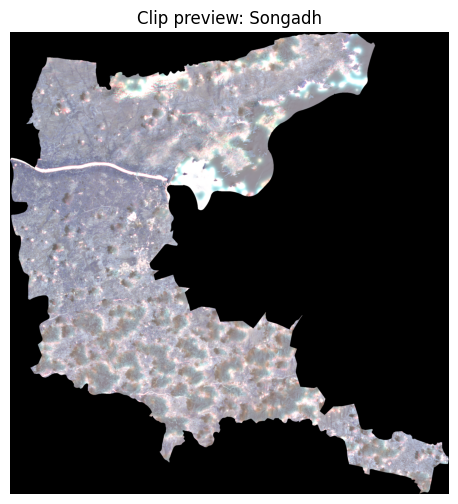

Saved clipped raster for 'Vyara':
  Local: ./_SD/Vyara.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Vyara.tif
  Per-band min/max: [(0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0)]


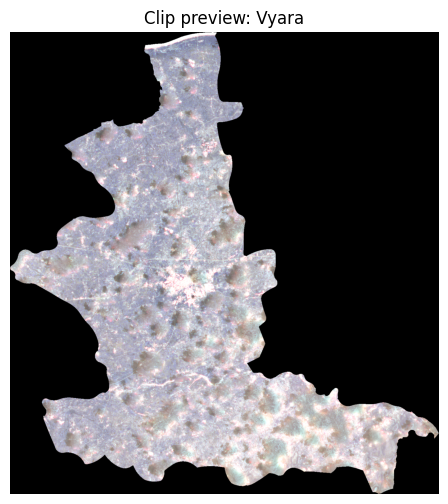

Saved clipped raster for 'Valod':
  Local: ./_SD/Valod.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Valod.tif
  Per-band min/max: [(0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0)]


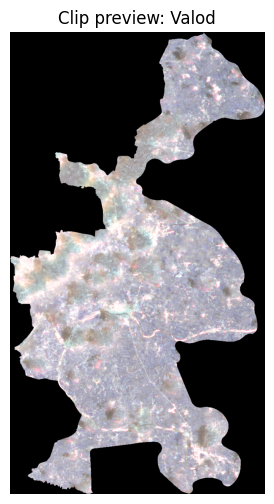

Saved clipped raster for 'Dolvan':
  Local: ./_SD/Dolvan.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Dolvan.tif
  Per-band min/max: [(0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0), (0.0, 255.0)]


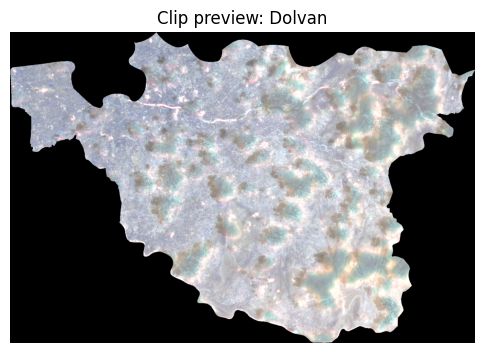


Summary of saved clipped files:
- Songadh:
  Local: ./_SD/Songadh.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Songadh.tif
- Vyara:
  Local: ./_SD/Vyara.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Vyara.tif
- Valod:
  Local: ./_SD/Valod.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Valod.tif
- Dolvan:
  Local: ./_SD/Dolvan.tif
  Drive: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD/Dolvan.tif


In [ ]:
# [O] Clip a georeferenced GeoTIFF into four specified subdistricts and save results.
# - Mounts Google Drive
# - Reads a raster (final VPint2 GeoTIFF) and a vector (shapefile/GeoJSON) containing subdistrict polygons
# - Filters the vector for the four subdistrict names found in your DBF (Songadh, Vyara, Valod, Dolvan)
# - Clips the raster to each polygon, saves GeoTIFFs locally and to Drive, and displays quick previews
#
# Instructions:
# 1. Upload your final GeoTIFF to Colab or set `src_raster` to its path.
# 2. Upload the vector file (shapefile: .shp + .shx + .dbf + .prj) or a GeoJSON and set `vector_path`.
# 3. Adjust `target_names` if you want different subdistricts.
# 4. Run the cell.
#
# Requirements (Colab): rasterio, geopandas, shapely, matplotlib, numpy, google.colab
# If a package is missing, install it first, e.g.:
#   !pip install rasterio geopandas shapely matplotlib

import os
from pathlib import Path
import shutil
import numpy as np
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Mount Google Drive (Colab) ---
## try:
##     from google.colab import drive
##     drive.mount('/content/drive', force_remount=False)
##     print("Google Drive mounted at /content/drive")
## except Exception:
##     print("Google Drive mount skipped (not running in Colab or google.colab not available).")

# === User configuration ===
## src_raster = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819.tif"   # <-- path to your final georeferenced GeoTIFF
src_raster = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_VIS/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819_VIS_PERCENT_8bit.tif"   # <-- path to your final georeferenced GeoTIFF
vector_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SHP/SUB_DISTR/surat_sd.shp"  # <-- path to your subdistrict shapefile or GeoJSON
drive_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_TIFF"  # <-- Drive folder to save outputs
local_out_dir = "./_SD"  # local output folder

# Subdistrict names to clip
target_names = ["Songadh", "Vyara", "Valod", "Dolvan"]

# Correct attribute field for names
name_field = "Sub_Distri"

# Create output directories
os.makedirs(local_out_dir, exist_ok=True)
if drive_path:
    Path(drive_path).mkdir(parents=True, exist_ok=True)

# --- Helper functions ---
def safe_name(s):
    if s is None:
        return "unknown"
    name = str(s).strip()
    for ch in ['/', '\\', ':', '*', '?', '"', '<', '>', '|']:
        name = name.replace(ch, '_')
    name = name.replace(' ', '_')
    return name[:120]

def clip_and_save(src_raster_path, geom, out_path):
    with rasterio.open(src_raster_path) as src:
        # Change nodata to 0 for uint8 compatibility
        out_image, out_transform = mask(src, [geom], crop=True, nodata=0)
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "compress": "lzw",
            "dtype": out_image.dtype,
            "nodata": 0 # Also set nodata in metadata
        })
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_image)
    return out_image, out_meta

# --- Main workflow ---
gdf = gpd.read_file(vector_path)
src = rasterio.open(src_raster)

# Reproject vector to raster CRS if needed
if gdf.crs != src.crs:
    print(f"Reprojecting vector from {gdf.crs} to raster CRS {src.crs}")
    gdf = gdf.to_crs(src.crs)

# Strip spaces from names
gdf[name_field] = gdf[name_field].astype(str).str.strip()

# Filter features by target names
matched = gdf[gdf[name_field].isin(target_names)]
print(f"Found {len(matched)} matching features for requested subdistricts.")

saved = []
for idx, row in matched.iterrows():
    attr_val = row[name_field]
    fname_safe = safe_name(attr_val)
    out_local = os.path.join(local_out_dir, f"{fname_safe}.tif")
    out_drive = os.path.join(drive_path, f"{fname_safe}.tif") if drive_path and os.path.exists('/content/drive') else None

    geom = row.geometry.__geo_interface__
    out_image, out_meta = clip_and_save(src.name, geom, out_local)

    if out_drive:
        shutil.copy2(out_local, out_drive)

    saved.append((attr_val, out_local, out_drive))
    print(f"Saved clipped raster for '{attr_val}':")
    print("  Local:", out_local)
    if out_drive:
        print("  Drive:", out_drive)

    # Quick verification: per-band min/max
    arr = out_image
    bands, H, W = arr.shape
    mins = [float(np.nanmin(arr[i])) if np.isfinite(arr[i]).any() else np.nan for i in range(bands)]
    maxs = [float(np.nanmax(arr[i])) if np.isfinite(arr[i]).any() else np.nan for i in range(bands)]
    print("  Per-band min/max:", list(zip(mins, maxs)))

    # Display preview (RGB if >=3 bands)
    if bands >= 3:
        def percentile_stretch(band, low=2, high=98):
            valid = band[np.isfinite(band)]
            if valid.size == 0:
                return np.zeros_like(band, dtype=np.uint8)
            lo = float(np.nanpercentile(valid, low))
            hi = float(np.nanpercentile(valid, high))
            if hi == lo:
                scaled = np.clip(band, 0, 255)
            else:
                scaled = (band - lo) / (hi - lo)
            return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)

        r = percentile_stretch(arr[0])
        g = percentile_stretch(arr[1])
        b = percentile_stretch(arr[2])
        rgb = np.dstack([r, g, b])
        plt.figure(figsize=(6,6))
        plt.imshow(rgb)
        plt.title(f"Clip preview: {attr_val}")
        plt.axis('off')
        plt.show()
    else:
        plt.figure(figsize=(6,6))
        plt.imshow(arr[0], cmap='gray')
        plt.title(f"Clip preview (single band): {attr_val}")
        plt.colorbar()
        plt.axis('off')
        plt.show()

# Summary
print("\nSummary of saved clipped files:")
for name, localp, drivep in saved:
    print(f"- {name}:\n  Local: {localp}\n  Drive: {drivep}")

In [ ]:
import geopandas as gpd
gdf = gpd.read_file("/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SHP/SUB_DISTR/surat_sd.shp")
print(gdf.columns)
print(gdf.head())

Index(['Subdistric', 'Sub_Distri', 'District_C', 'District', 'state_code',
       'State', 'Total_Numb', 'Total_Popu', 'Average_Ho', 'Total_Geog',
       'Forest_Are', 'Area_under', 'Barren___U', 'Permanent_', 'Land_Under',
       'Culturable', 'Fallows_La', 'Current_Fa', 'Net_Area_S', 'Total_Unir',
       'Area_Irrig', 'Canals_Are', 'Wells_Tube', 'Tanks_Lake', 'Waterfall_',
       'Unique', 'st_area_sh', 'st_length_', 'geometry'],
      dtype='object')
  Subdistric Sub_Distri District_C District state_code State  Total_Numb  \
0       3944    Songadh        641     Tapi         24    GJ     49427.0   
1       3945      Vyara        641     Tapi         24    GJ     38718.0   
2       3946      Valod        641     Tapi         24    GJ     20168.0   
3       6200     Dolvan        641     Tapi         24    GJ     20242.0   

   Total_Popu  Average_Ho  Total_Geog  ...  Total_Unir  Area_Irrig  \
0    229782.0  805.776420    117989.0  ...     31261.0      9622.0   
1    175587.0  409.84

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive
Vector CRS: EPSG:32643
Available name values (sample): ['Songadh', 'Vyara', 'Valod', 'Dolvan']

Processing district: Songadh (index 0)
  Reading cloudy product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


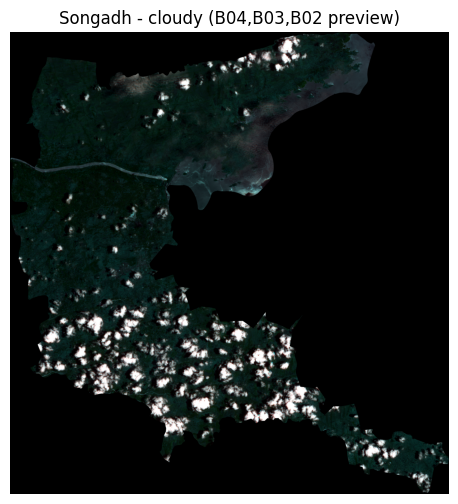

  Reading cloudfree product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:20m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


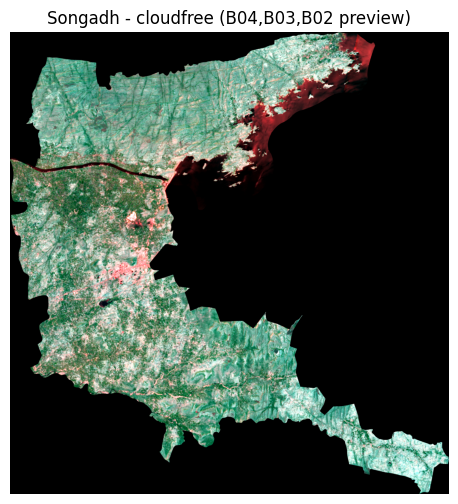


Processing district: Vyara (index 1)
  Reading cloudy product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:20m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


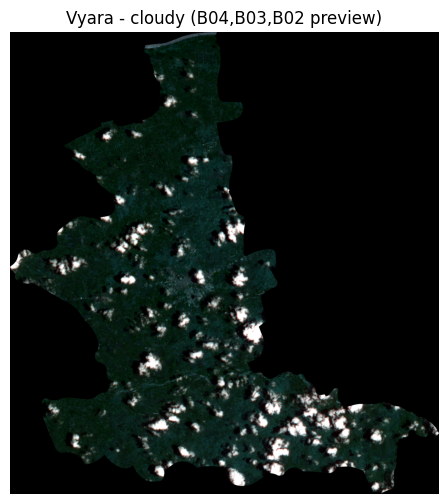

  Reading cloudfree product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:20m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


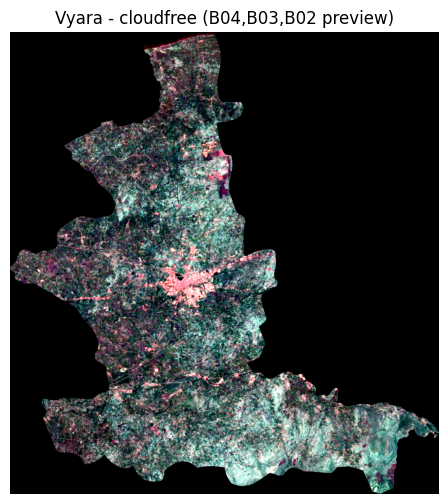


Processing district: Valod (index 2)
  Reading cloudy product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:20m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


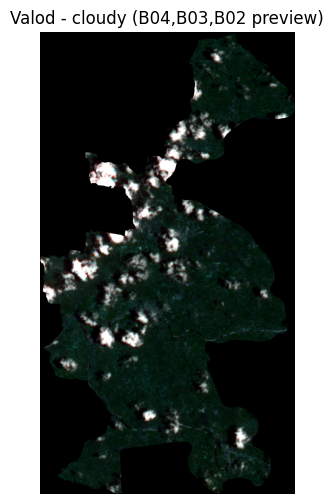

  Reading cloudfree product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:20m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


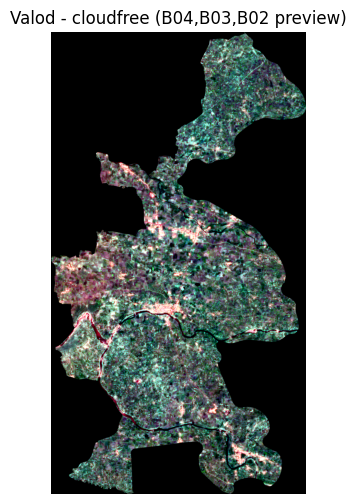


Processing district: Dolvan (index 3)
  Reading cloudy product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.SAFE/MTD_MSIL2A.xml:20m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T05425

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


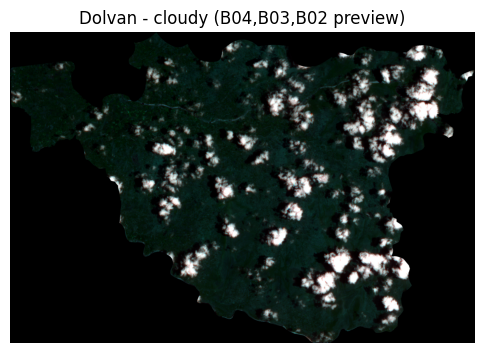

  Reading cloudfree product: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip
   Using subdatasets:
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:10m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.SAFE/MTD_MSIL2A.xml:20m:EPSG_32643
     SENTINEL2_L2A:/vsizip//content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.

/tmp/ipython-input-2633939160.py:162: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


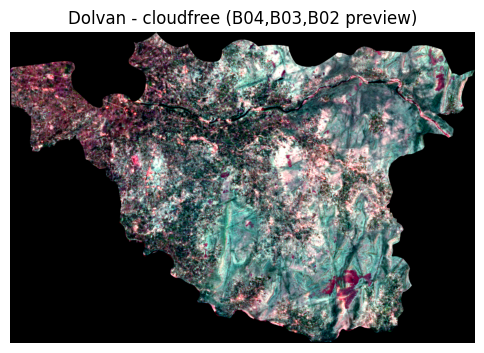

In [ ]:
# [P] Clip Sentinel-2 SAFE ZIP products district-wise (B02, B03, B04 only)
# - Mounts Google Drive
# - Installs missing packages if needed (guarded)
# - Reads SAFE ZIP subdatasets (JP2s) and selects B02, B03, B04 (prefers 10m)
# - Resamples bands to a common grid if shapes differ
# - Clips each target district polygon, saves multi-band GeoTIFFs locally and to Drive
# - Displays percentile-stretched RGB previews (2-98%) and prints per-band min/max and saved paths
#
# Edit the "User configuration" section below with your paths and target district names, then run.

import sys
import subprocess
import importlib
import os
from pathlib import Path
import shutil
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Install required packages if missing (safe for Colab)
for pkg in ("rasterio", "geopandas", "shapely", "matplotlib", "numpy"):
    try:
        importlib.import_module(pkg)
    except Exception:
        pip_install(pkg)

# Optional VPint utilities (if available)
vpint_available = True
try:
    from VPint.utils.EO_utils import load_product, normalise_and_visualise
except Exception:
    vpint_available = False

# Now import modules
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.enums import Resampling
from rasterio.warp import reproject
import geopandas as gpd
import matplotlib.pyplot as plt

# === User configuration (EDIT THESE PATHS) ===
cloudy_zip = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip"
cloudfree_zip = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/RF_SET-1_2025-MAR-14/S2A_MSIL2A_20250314T054241_N0511_R005_T43QCD_20250314T103620.zip"
vector_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SHP/SUB_DISTR/surat_sd.shp"
target_names = ["Songadh", "Vyara", "Valod", "Dolvan"]   # district list to process
name_field = "Sub_Distri"                                # attribute field with names
drive_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_SAFE"  # Drive output folder
local_out_dir = "./_SD_SAFE"                             # local output folder

# Bands to check (only B02, B03, B04)
band_tokens = ["_B02_", "_B03_", "_B04_"]  # case-insensitive matching
# RGB order for preview: B04 (red), B03 (green), B02 (blue) -> indices will be (2,1,0) if stacked in B02,B03,B04 order
rgb_band_order = (2, 1, 0)
percentile_low, percentile_high = 2, 98
preferred_resolution_token = ":10m:"  # prefer 10m subdatasets

# --- Mount Google Drive (Colab) ---
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("Google Drive mounted at /content/drive")
except Exception:
    print("Drive mount skipped or not running in Colab.")

# Create output directories
os.makedirs(local_out_dir, exist_ok=True)
if drive_path:
    Path(drive_path).mkdir(parents=True, exist_ok=True)

# --- Helper functions ---
def safe_filename(s):
    s = str(s)
    return "".join(c if c.isalnum() or c in (" ", "_", "-") else "_" for c in s).strip().replace(" ", "_")[:120]

def find_band_subdatasets(zip_path, tokens, preferred_resolution=":10m:"):
    """Return ordered list of subdataset names matching tokens and preferred_resolution (case-insensitive)."""
    with rasterio.open(zip_path) as z:
        sds = z.subdatasets or []
    sds_lower = [(sd, sd.lower()) for sd in sds]
    # First try to find tokens at preferred resolution (e.g., ':10m:')
    found = []
    for token in tokens:
        token_l = token.lower()
        match = [sd for sd, sd_l in sds_lower if token_l in sd_l and preferred_resolution in sd_l]
        if match:
            found.append(match[0])
    # If not all found at preferred resolution, try matching tokens anywhere
    if len(found) < len(tokens):
        for token in tokens:
            token_l = token.lower()
            match = [sd for sd, sd_l in sds_lower if token_l in sd_l]
            for m in match:
                if m not in found:
                    found.append(m)
    # Fallback: if still empty, use first 3 subdatasets
    if not found:
        return sds[:3]
    # Ensure order follows tokens
    ordered = []
    for token in tokens:
        for sd in found:
            if token.lower() in sd.lower() and sd not in ordered:
                ordered.append(sd)
    for sd in found:
        if sd not in ordered:
            ordered.append(sd)
    return ordered

def read_and_stack_subdatasets(subdataset_paths):
    """
    Read list of rasterio subdataset paths and stack into numpy array (bands, H, W).
    If shapes differ, resample each band to the first band's shape/transform.
    """
    arrays = []
    meta_ref = None

    if not subdataset_paths:
        raise RuntimeError("No subdatasets provided.")
    # Reference: first subdataset
    with rasterio.open(subdataset_paths[0]) as src0:
        ref_height = src0.height
        ref_width = src0.width
        ref_transform = src0.transform
        ref_crs = src0.crs
        meta_ref = src0.meta.copy()

    for sd in subdataset_paths:
        with rasterio.open(sd) as src:
            if src.width == ref_width and src.height == ref_height and src.crs == ref_crs:
                arr = src.read(1).astype(np.float32)
            else:
                # Resample/reproject to reference grid
                arr = np.empty((ref_height, ref_width), dtype=np.float32)
                reproject(
                    source=rasterio.band(src, 1),
                    destination=arr,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=ref_transform,
                    dst_crs=ref_crs,
                    resampling=Resampling.bilinear
                )
            arrays.append(arr)
    stack = np.stack(arrays, axis=0)
    return stack, meta_ref

def percentile_stretch_uint8(band, low=2, high=98):
    valid = band[np.isfinite(band)]
    if valid.size == 0:
        return np.zeros_like(band, dtype=np.uint8)
    lo = float(np.nanpercentile(valid, low))
    hi = float(np.nanpercentile(valid, high))
    if hi == lo:
        scaled = np.clip(band, 0, 255)
    else:
        scaled = (band - lo) / (hi - lo)
    return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)

def save_geotiff(path, arr, meta, compress="lzw"):
    """Save arr (bands, H, W) with meta updated. Keeps dtype from arr if valid."""
    out_meta = meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": arr.shape[1],
        "width": arr.shape[2],
        "count": arr.shape[0],
        "compress": compress,
        "dtype": arr.dtype
    })
    with rasterio.open(path, "w", **out_meta) as dst:
        for i in range(arr.shape[0]):
            dst.write(arr[i], i+1)

def mask_stack_with_geom(stack_meta, stack_array, geom):
    """Mask a stacked array (bands, H, W) using rasterio.mask.mask via an in-memory dataset."""
    from rasterio.io import MemoryFile
    profile = stack_meta.copy()
    profile.update({
        "driver": "GTiff",
        "count": stack_array.shape[0],
        "dtype": stack_array.dtype
    })
    with MemoryFile() as memfile:
        with memfile.open(**profile) as dataset:
            for i in range(stack_array.shape[0]):
                dataset.write(stack_array[i], i+1)
            out_image, out_transform = mask(dataset, [geom], crop=True, nodata=np.nan)
            out_meta = dataset.meta.copy()
            out_meta.update({
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
    return out_image, out_meta

# --- Load vector and prepare matching ---
gdf = gpd.read_file(vector_path)
if gdf.crs is None:
    raise RuntimeError("Vector has no CRS. Ensure shapefile has .prj or set CRS before running.")
print("Vector CRS:", gdf.crs)

# Normalize name field and prepare lookup (case-insensitive)
gdf[name_field] = gdf[name_field].astype(str).str.strip()
available_names = list(gdf[name_field].unique())
print("Available name values (sample):", available_names)

name_map = {str(v).strip().lower(): idx for idx, v in gdf[name_field].items()}

# --- Main loop: process each district name ---
for target in target_names:
    key = str(target).strip().lower()
    if key not in name_map:
        print(f"\nTarget '{target}' not found in vector attribute '{name_field}'. Available values (first 20):")
        print(available_names[:20])
        print("Skipping", target)
        continue

    row_idx = name_map[key]
    row = gdf.loc[row_idx]
    geom = row.geometry.__geo_interface__
    district_safe = safe_filename(row[name_field])
    print(f"\nProcessing district: {row[name_field]} (index {row_idx})")

    for label, zip_path in [("cloudy", cloudy_zip), ("cloudfree", cloudfree_zip)]:
        if not os.path.exists(zip_path):
            print(f"  Source not found: {zip_path}. Skipping {label}.")
            continue

        print(f"  Reading {label} product: {zip_path}")
        # Find subdatasets for B02,B03,B04 preferring 10m
        sds = find_band_subdatasets(zip_path, band_tokens, preferred_resolution=preferred_resolution_token)
        if not sds:
            print("   No subdatasets found in SAFE ZIP. Skipping.")
            continue
        # Ensure we have at least 3 bands; if fewer, fallback to first 3 subdatasets
        if len(sds) < 3:
            with rasterio.open(zip_path) as z:
                sds = z.subdatasets[:3]
            print("   Fallback to first 3 subdatasets for preview.")

        print("   Using subdatasets:")
        for sd in sds:
            print("    ", sd.split("|")[-1])

        # Read and stack (resampling to reference if needed)
        try:
            stack, meta = read_and_stack_subdatasets(sds)
        except Exception as e:
            print("   Failed to read subdatasets:", e)
            continue

        # Mask with geometry (crop)
        try:
            out_stack, out_meta = mask_stack_with_geom(meta, stack, geom)
        except Exception as e:
            print("   Masking failed:", e)
            continue

        # Save outputs
        out_local = os.path.join(local_out_dir, f"{district_safe}_{label}.tif")
        out_drive = os.path.join(drive_path, f"{district_safe}_{label}.tif") if drive_path else None

        # Preserve dtype (float32) to avoid NaN->int issues; user can convert later if desired
        try:
            save_geotiff(out_local, out_stack, out_meta, compress="lzw")
            if out_drive:
                shutil.copy2(out_local, out_drive)
        except Exception as e:
            print("   Saving failed:", e)
            continue

        print(f"   Saved: local={out_local}")
        if out_drive:
            print(f"          drive={out_drive}")

        # Print per-band min/max (ignoring NaNs)
        for b in range(out_stack.shape[0]):
            band = out_stack[b]
            valid = band[np.isfinite(band)]
            if valid.size:
                print(f"    Band {b+1} min/max: {float(np.nanmin(valid))} / {float(np.nanmax(valid))}")
            else:
                print(f"    Band {b+1} has no valid pixels")

        # Display RGB preview (percentile stretch)
        try:
            bands_count = out_stack.shape[0]
            if bands_count >= 3:
                # Determine indices for RGB preview (use rgb_band_order clipped to available bands)
                idxs = tuple(min(max(0, i), bands_count-1) for i in rgb_band_order)
                r = percentile_stretch_uint8(out_stack[idxs[0]], percentile_low, percentile_high)
                g = percentile_stretch_uint8(out_stack[idxs[1]], percentile_low, percentile_high)
                b = percentile_stretch_uint8(out_stack[idxs[2]], percentile_low, percentile_high)
                rgb = np.dstack([r, g, b])
                plt.figure(figsize=(6,6))
                plt.imshow(rgb)
                plt.title(f"{row[name_field]} - {label} (B04,B03,B02 preview)")
                plt.axis("off")
                plt.show()
            else:
                band0 = out_stack[0]
                plt.figure(figsize=(6,6))
                plt.imshow(band0, cmap="gray")
                plt.title(f"{row[name_field]} - {label} (single band)")
                plt.colorbar()
                plt.axis("off")
                plt.show()
        except Exception as e:
            print("   Preview failed:", e)

# --- Optional: change bands or percentiles ---
# To change bands used for stacking, edit `band_tokens` above, e.g.:
# band_tokens = ["_B08_", "_B04_", "_B03_"]  # NIR, Red, Green
# To change percentile stretch, edit percentile_low and percentile_high variables.
# To save as uint8 after stretching, convert out_stack to uint8 using percentile_stretch_uint8 per band before save.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive
Vector CRS: EPSG:32643
Available name values (sample): ['Songadh', 'Vyara', 'Valod', 'Dolvan']
Source raster bands: 12, CRS: EPSG:32643

Processing district: Songadh (index 0)
  Saved: local=./_SD_TIFF/Songadh_VPint2.tif
         drive=/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_TIFF/Songadh_VPint2.tif
    Band 2 min/max: 411.0 / 12268.0
    Band 3 min/max: 432.0 / 12244.0
    Band 4 min/max: 434.0 / 12432.0


/tmp/ipython-input-2356263602.py:81: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


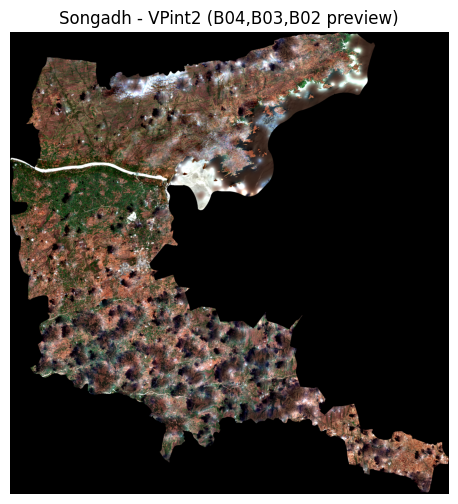


Processing district: Vyara (index 1)
  Saved: local=./_SD_TIFF/Vyara_VPint2.tif
         drive=/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_TIFF/Vyara_VPint2.tif
    Band 2 min/max: 231.0 / 14858.0
    Band 3 min/max: 258.0 / 15442.0
    Band 4 min/max: 400.0 / 15387.0


/tmp/ipython-input-2356263602.py:81: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


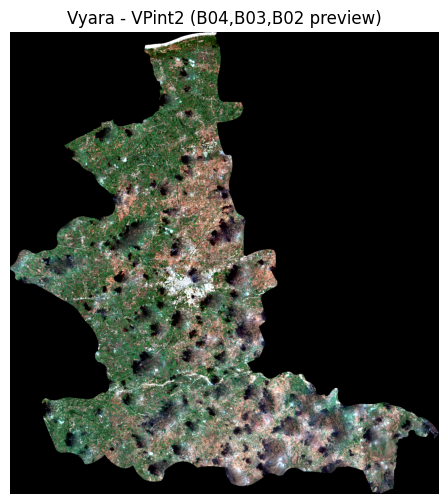


Processing district: Valod (index 2)
  Saved: local=./_SD_TIFF/Valod_VPint2.tif
         drive=/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_TIFF/Valod_VPint2.tif
    Band 2 min/max: 429.0 / 9435.0
    Band 3 min/max: 431.0 / 9614.0
    Band 4 min/max: 433.0 / 9299.0


/tmp/ipython-input-2356263602.py:81: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


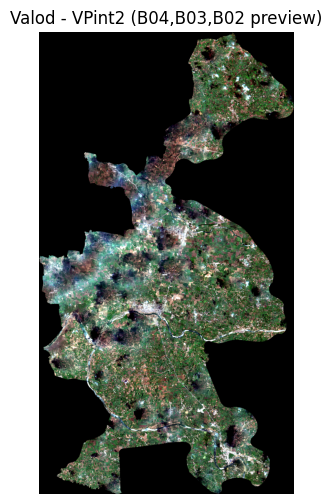


Processing district: Dolvan (index 3)
  Saved: local=./_SD_TIFF/Dolvan_VPint2.tif
         drive=/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_TIFF/Dolvan_VPint2.tif
    Band 2 min/max: 440.0 / 8285.0
    Band 3 min/max: 978.0 / 8735.0
    Band 4 min/max: 436.0 / 8976.0


/tmp/ipython-input-2356263602.py:81: RuntimeWarning: invalid value encountered in cast
  return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)


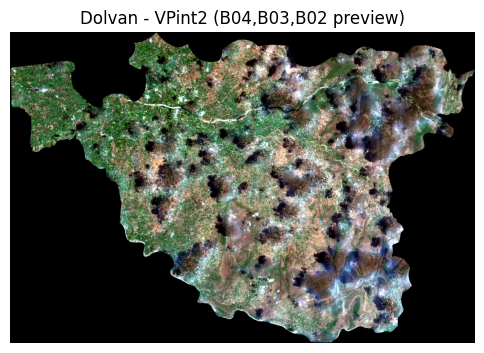


Done. Clipped VPint2 GeoTIFF saved per district in:
 Local folder: /content/_SD_TIFF
 Drive folder: /content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_TIFF


In [ ]:
# [Q] This is simlar to [O], Clip VPint2 GeoTIFF into B02,B03,B04 bands per subdistrict and save to Drive
# - Mounts Google Drive
# - Installs missing packages if needed (guarded)
# - Reads VPint2 GeoTIFF, selects specified band indices (default: first 3 bands)
# - Clips each target district polygon, saves multi-band GeoTIFFs locally and to Drive
# - Displays percentile-stretched RGB previews (2-98%) and prints per-band min/max and saved paths
#
# Edit the "User configuration" section below with your paths and target district names, then run.

import sys
import subprocess
import importlib
import os
from pathlib import Path
import shutil
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Install required packages if missing (safe for Colab)
for pkg in ("rasterio", "geopandas", "shapely", "matplotlib", "numpy"):
    try:
        importlib.import_module(pkg)
    except Exception:
        pip_install(pkg)

# Now import modules
import numpy as np
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

# === User configuration (EDIT THESE PATHS) ===
src_raster = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/VPint2_InPolated_AutoAdap_SURAT_T43QCD_20250513T090819.tif"
vector_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SHP/SUB_DISTR/surat_sd.shp"
drive_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/COLAB/VPint2_Output/_SD_TIFF"
local_out_dir = "./_SD_TIFF"
# Subdistrict names to clip (adjust if needed)
target_names = ["Songadh", "Vyara", "Valod", "Dolvan"]
name_field = "Sub_Distri"  # attribute field with names in shapefile

# Band indices to extract from VPint2 GeoTIFF (1-based). Default assumes bands 1,2,3 correspond to B02,B03,B04.
# To get B2, B3, B4 (True Color), use indices 2, 3, 4 from the 12-band VPint2 output.
band_indices = [2, 3, 4]

# RGB preview order (indices into the stacked array, 0-based). For B02,B03,B04 stacked in that order, use (2,1,0) -> B04,B03,B02
rgb_band_order = (2, 1, 0)
percentile_low, percentile_high = 2, 98

# --- Mount Google Drive (Colab) ---
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("Google Drive mounted at /content/drive")
except Exception:
    print("Drive mount skipped or not running in Colab.")

# Create output directories
os.makedirs(local_out_dir, exist_ok=True)
if drive_path:
    Path(drive_path).mkdir(parents=True, exist_ok=True)

# --- Helper functions ---
def safe_filename(s):
    s = str(s)
    return "".join(c if c.isalnum() or c in (" ", "_", "-") else "_" for c in s).strip().replace(" ", "_")[:120]

def percentile_stretch_uint8(band, low=2, high=98):
    valid = band[np.isfinite(band)]
    if valid.size == 0:
        return np.zeros_like(band, dtype=np.uint8)
    lo = float(np.nanpercentile(valid, low))
    hi = float(np.nanpercentile(valid, high))
    if hi == lo:
        scaled = np.clip(band, 0, 255)
    else:
        scaled = (band - lo) / (hi - lo)
    return np.clip(scaled * 255.0, 0, 255).astype(np.uint8)

def save_geotiff(path, arr, meta, compress="lzw"):
    """Save arr (bands, H, W) with meta updated. Keeps dtype from arr if valid."""
    out_meta = meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": arr.shape[1],
        "width": arr.shape[2],
        "count": arr.shape[0],
        "compress": compress,
        "dtype": arr.dtype
    })
    with rasterio.open(path, "w", **out_meta) as dst:
        for i in range(arr.shape[0]):
            dst.write(arr[i], i+1)

# --- Load vector and prepare matching ---
gdf = gpd.read_file(vector_path)
if gdf.crs is None:
    raise RuntimeError("Vector has no CRS. Ensure shapefile has .prj or set CRS before running.")
print("Vector CRS:", gdf.crs)

# Normalize name field and prepare lookup (case-insensitive)
gdf[name_field] = gdf[name_field].astype(str).str.strip()
available_names = list(gdf[name_field].unique())
print("Available name values (sample):", available_names)

name_map = {str(v).strip().lower(): idx for idx, v in gdf[name_field].items()}

# --- Open source raster once to inspect bands ---
if not os.path.exists(src_raster):
    raise FileNotFoundError(f"Source raster not found: {src_raster}")

with rasterio.open(src_raster) as src:
    src_count = src.count
    src_crs = src.crs
    src_meta = src.meta.copy()
    print(f"Source raster bands: {src_count}, CRS: {src_crs}")
    if max(band_indices) > src_count:
        raise ValueError(f"Requested band index {max(band_indices)} exceeds source band count {src_count}.")

# Reproject vector to raster CRS if needed
if gdf.crs != src_crs:
    print(f"Reprojecting vector from {gdf.crs} to raster CRS {src_crs}")
    gdf = gdf.to_crs(src_crs)

# --- Main loop: process each district name ---
for target in target_names:
    key = str(target).strip().lower()
    if key not in name_map:
        print(f"\nTarget '{target}' not found in vector attribute '{name_field}'. Available values (first 20):")
        print(available_names[:20])
        print("Skipping", target)
        continue

    row_idx = name_map[key]
    row = gdf.loc[row_idx]
    geom = row.geometry.__geo_interface__
    district_safe = safe_filename(row[name_field])
    print(f"\nProcessing district: {row[name_field]} (index {row_idx})")

    # Clip using rasterio.mask.mask with indexes parameter
    try:
        with rasterio.open(src_raster) as src:
            # mask supports indexes parameter (1-based band indices)
            out_image, out_transform = mask(src, [geom], crop=True, nodata=np.nan, indexes=band_indices)
            # out_image shape: (bands, H, W)
            out_meta = src.meta.copy()
            out_meta.update({
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "count": out_image.shape[0],
                "dtype": out_image.dtype,
                "compress": "lzw"
            })
    except Exception as e:
        print("  Clipping failed for district", row[name_field], ":", e)
        continue

    # Save outputs
    out_local = os.path.join(local_out_dir, f"{district_safe}_VPint2.tif")
    out_drive = os.path.join(drive_path, f"{district_safe}_VPint2.tif") if drive_path else None

    # Ensure dtype is valid for saving; keep float32 if present
    try:
        save_geotiff(out_local, out_image, out_meta, compress="lzw")
        if out_drive:
            shutil.copy2(out_local, out_drive)
    except Exception as e:
        print("  Saving failed:", e)
        continue

    print(f"  Saved: local={out_local}")
    if out_drive:
        print(f"         drive={out_drive}")

    # Print per-band min/max (ignoring NaNs)
    for b in range(out_image.shape[0]):
        band = out_image[b]
        valid = band[np.isfinite(band)]
        if valid.size:
            print(f"    Band {band_indices[b]} min/max: {float(np.nanmin(valid))} / {float(np.nanmax(valid))}")
        else:
            print(f"    Band {band_indices[b]} has no valid pixels")

    # Display RGB preview (percentile stretch)
    try:
        bands_count = out_image.shape[0]
        if bands_count >= 3:
            idxs = tuple(min(max(0, i), bands_count-1) for i in rgb_band_order)
            r = percentile_stretch_uint8(out_image[idxs[0]], percentile_low, percentile_high)
            g = percentile_stretch_uint8(out_image[idxs[1]], percentile_low, percentile_high)
            b = percentile_stretch_uint8(out_image[idxs[2]], percentile_low, percentile_high)
            rgb = np.dstack([r, g, b])
            plt.figure(figsize=(6,6))
            plt.imshow(rgb)
            plt.title(f"{row[name_field]} - VPint2 (B04,B03,B02 preview)")
            plt.axis("off")
            plt.show()
        else:
            band0 = out_image[0]
            plt.figure(figsize=(6,6))
            plt.imshow(band0, cmap="gray")
            plt.title(f"{row[name_field]} - VPint2 (single band)")
            plt.colorbar()
            plt.axis("off")
            plt.show()
    except Exception as e:
        print("  Preview failed:", e)

# Summary
print("\nDone. Clipped VPint2 GeoTIFF saved per district in:")
print(" Local folder:", os.path.abspath(local_out_dir))
if drive_path:
    print(" Drive folder:", drive_path)

# --- Optional notes ---
# - If your VPint2 GeoTIFF bands are not in the expected order, change `band_indices` accordingly (1-based).
# - To save as uint8 after stretching, convert each band using percentile_stretch_uint8 before calling save_geotiff.
# - To clip additional districts, add them to `target_names`.

In [ ]:
###EXTRA TESTING
e
import rasterio
from rasterio.transform import Affine
import geopandas as gpd
import numpy as np

# --- Start of added code to define original_crs and original_transform ---
# Define the path to the target satellite imagery data (cloudy image)
target_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SAFE_ZIP/CL_SET-2_2025-MAY-13/S2A_MSIL2A_20250513T054251_N0511_R005_T43QCD_20250513T090819.zip"

# Extract georeferencing information from one of the subdatasets of the target product
original_transform = None
original_crs = None
with rasterio.open(target_path) as raw_product:
    product_subdatasets = raw_product.subdatasets
    if product_subdatasets:
        # Open the first subdataset to get its transform and CRS
        with rasterio.open(product_subdatasets[0]) as src:
            original_transform = src.transform
            original_crs = src.crs
# --- End of added code ---


# Path to the subdistrict shapefile (already defined in context, ensuring it's accessible)
vector_path = "/content/drive/MyDrive/IIIT/2026_ORS/EarthLens/Assignment-II/DATASET/SURAT/SHP/SUB_DISTR/surat_sd.shp"
name_field = "Sub_Distri"
target_district = "Songadh"

# Load the subdistrict shapefile
gdf = gpd.read_file(vector_path)

# Ensure CRS matches the original Sentinel-2 data's CRS (which is EPSG:32643 for this tile)
# original_crs and original_transform are available from Section F's execution
gdf_reprojected = gdf.to_crs(original_crs)

# Get the geometry for Songadh
songadh_geom = gdf_reprojected[gdf_reprojected[name_field].str.strip() == target_district].geometry.iloc[0]

# Get the bounding box of the Songadh geometry in projected coordinates
minx, miny, maxx, maxy = songadh_geom.bounds

# Convert bbox corners to pixel coordinates using the original_transform (10m resolution)
# rasterio.transform.rowcol takes (transform, x, y)
# Top-left pixel of the bounding box (rows increase downwards, so use maxy for row_start)
col_start_10m, row_start_10m = ~original_transform * (minx, maxy)

# Bottom-right pixel of the bounding box (rows increase downwards, so use miny for row_end)
col_end_10m, row_end_10m = ~original_transform * (maxx, miny)

# Convert to integers and determine the window size and offset
# Round down for start to ensure the window starts within or exactly at the feature boundary.
# Round up for end to ensure the window ends within or exactly at the feature boundary.
# Add 1 to size calculations because coordinates are inclusive.

y_offset = max(0, int(np.floor(row_start_10m)))
x_offset = max(0, int(np.floor(col_start_10m)))
y_size = int(np.ceil(row_end_10m)) - y_offset + 1
x_size = int(np.ceil(col_end_10m)) - x_offset + 1

print(f"For Songadh district (10m pixel coordinates relative to the full 10m image grid):")
print(f"y_size: {y_size}")
print(f"x_size: {x_size}")
print(f"y_offset: {y_offset}")
print(f"x_offset: {x_offset}")

# The calculated values can now be used in Section G-1 for load_product_windowed.
# For example:
# y_size_songadh = {y_size}
# x_size_songadh = {x_size}
# y_offset_songadh = {y_offset}
# x_offset_songadh = {x_offset}


For Songadh district (10m pixel coordinates relative to the full 10m image grid):
y_size: 5382
x_size: 5107
y_offset: 3163
x_offset: 3551
